In [3]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!
import pickle
import datetime
from logic import gwyfile as gwy
import numpy as np
from scipy.signal import find_peaks
from lmfit import Parameters

### Plot single T1 curve

In [16]:
filebeginning = '20251027-1144-44_T1-dark-init-alt-exp-point-by-point_A-S07-29_YBCO_S1_82K_5mT_OOP_Z_lift_off_5e-09_Meissner_pulsed_measurement' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[4:6]
file_day = filebeginning[6:8]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\PulsedMeasurement\\'
filepath = path + filebeginning + '.dat'

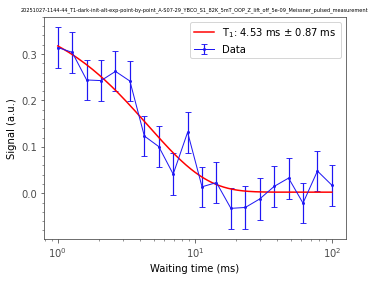

In [18]:
offset_zero = False

data_raw = np.loadtxt(filepath).T
var_list = data_raw[0]

plt.rcParams.update({'font.size': 10})
fig = plt.figure(figsize = (5, 4))

plot_option = 3 #1 = Signal1, 2 = Signal2, 3 = delta of signals
err = None

var_list_more = np.linspace(var_list[0],var_list[-1],1000)

#Choose what to plot
if plot_option == 3:
    data = data_raw[1] - data_raw[2]
    shift = (data_raw.shape[0]-1)//2
    err1 = abs(data_raw[1+shift])
    err2 = abs(data_raw[2+shift])
    err = err1+err2
else:
    data = data_raw[plot_option]
    shift = (data_raw.shape[0]-1)//2
    err = data_raw[plot_option+shift]
    
params = Parameters()
if offset_zero:
    params.add('offset', value = 0, vary = False)
fit = fitlogic.make_decayexponential_fit(var_list,data,estimator=fitlogic.estimate_decayexponential, add_params = params)
lm,_ = fitlogic.make_decayexponential_model()
temp = lm.eval(fit.params, x=var_list_more)

ax1 = fig.add_subplot()
ax1.set_xscale('log')

ax1.set_xlabel('Waiting time (ms)')
ax1.set_ylabel('Signal (a.u.)')

ax1.errorbar(x=var_list*1e3, y=data,
                         yerr=err, fmt='-o',
                         capsize=3, capthick=0.9,
                        elinewidth=1.2, markersize=3, linewidth=1.0, label="Data")
leg = f"T$_1$: {round(fit.params['lifetime']*1e3,2)} ms $\pm$ {round(fit.params['lifetime'].stderr*1e3,2)} ms"
ax1.plot(var_list_more*1e3, temp,'r-', linewidth=1.5, label=leg)

ax1.legend()
ax1.title.set_text(filebeginning)
ax1.title.set_size(5)

plt.tight_layout()

if offset_zero:
    save_name = path + filebeginning+'_log_scale_fit_offset_zero.png'
else:
    save_name = path + filebeginning+'_log_scale_fit.png'
with open(save_name, 'wb') as f:
    plt.savefig(f,format='png')

plt.show()

### Plot two normalized T1 curves for comparison

In [19]:
filebeginning = '20251024-0925-30_T1-dark-init-alt-exp-point-by-point_A-S07-29_YBCO_S1_82K_5mT_OOP_OOC_pulsed_measurement' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[4:6]
file_day = filebeginning[6:8]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\PulsedMeasurement\\'
filepath = path + filebeginning + '.dat'

filebeginning_2 = '20251027-1144-44_T1-dark-init-alt-exp-point-by-point_A-S07-29_YBCO_S1_82K_5mT_OOP_Z_lift_off_5e-09_Meissner_pulsed_measurement' #here the beginning of the filename, including the date and sample name, is needed

file_year_2 = filebeginning_2[0:4]
file_month_2 = filebeginning_2[4:6]
file_day_2 = filebeginning_2[6:8]
path_2 = 'G:\\Data\\Qudi_Data\\'+file_year_2+'\\'+file_month_2+'\\'+file_year_2+file_month_2+file_day_2+'\\PulsedMeasurement\\'
filepath_2 = path_2 + filebeginning_2 + '.dat'

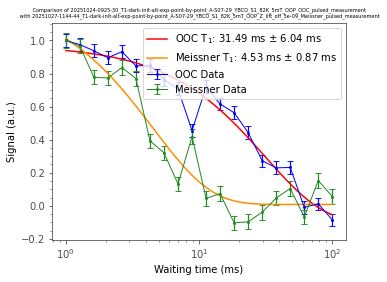

In [21]:
data_extra = 'OOC'
data_extra_2 = 'Meissner'
offset_zero = False

plt.rcParams.update({'font.size': 10})
fig = plt.figure(figsize = (5, 4))

plot_option = 3 #1 = Signal1, 2 = Signal2, 3 = delta of signals
err = None

data_raw = np.loadtxt(filepath).T
var_list = data_raw[0]

var_list_more = np.linspace(var_list[0],var_list[-1],1000)

#Choose what to plot
if plot_option == 3:
    data = data_raw[1] - data_raw[2]
    shift = (data_raw.shape[0]-1)//2
    err1 = abs(data_raw[1+shift])
    err2 = abs(data_raw[2+shift])
    err = err1+err2
else:
    data = data_raw[plot_option]
    shift = (data_raw.shape[0]-1)//2
    err = data_raw[plot_option+shift]
    
params = Parameters()
if offset_zero:
    params.add('offset', value = 0, vary = False)
    
fit = fitlogic.make_decayexponential_fit(var_list,data,estimator=fitlogic.estimate_decayexponential, add_params = params)
lm,_ = fitlogic.make_decayexponential_model()
temp = lm.eval(fit.params, x=var_list_more)

ax1 = fig.add_subplot()
ax1.set_xscale('log')

ax1.set_xlabel('Waiting time (ms)')
ax1.set_ylabel('Signal (a.u.)')

leg = f'{data_extra} Data'

ax1.errorbar(x=var_list*1e3, y=data/data[0],
                         yerr=err, fmt='-o',
                         capsize=3, capthick=0.9, color = 'blue',
                        elinewidth=1.2, markersize=3, linewidth=1.0, label = leg)
leg = f"{data_extra} T$_1$: {round(fit.params['lifetime']*1e3,2)} ms $\pm$ {round(fit.params['lifetime'].stderr*1e3,2)} ms"
ax1.plot(var_list_more*1e3, temp/data[0],'-', linewidth=1.5, label=leg, color = 'red')

data_raw = np.loadtxt(filepath_2).T
var_list = data_raw[0]

var_list_more = np.linspace(var_list[0],var_list[-1],1000)

#Choose what to plot
if plot_option == 3:
    data = data_raw[1] - data_raw[2]
    shift = (data_raw.shape[0]-1)//2
    err1 = abs(data_raw[1+shift])
    err2 = abs(data_raw[2+shift])
    err = err1+err2
else:
    data = data_raw[plot_option]
    shift = (data_raw.shape[0]-1)//2
    err = data_raw[plot_option+shift]
    
fit = fitlogic.make_decayexponential_fit(var_list,data,estimator=fitlogic.estimate_decayexponential, add_params = params)
lm,_ = fitlogic.make_decayexponential_model()
temp = lm.eval(fit.params, x=var_list_more)

leg = f'{data_extra_2} Data'
ax1.errorbar(x=var_list*1e3, y=data/data[0],
                         yerr=err, fmt='-o',
                         capsize=3, capthick=0.9, color = 'forestgreen',
                        elinewidth=1.2, markersize=3, linewidth=1.0, label=leg)
leg = f"{data_extra_2} T$_1$: {round(fit.params['lifetime']*1e3,2)} ms $\pm$ {round(fit.params['lifetime'].stderr*1e3,2)} ms"
ax1.plot(var_list_more*1e3, temp/data[0],'r-', linewidth=1.5, label=leg, color = 'darkorange')

ax1.legend()
ax1.title.set_text(f' Comparison of {filebeginning} \n with {filebeginning_2}')
ax1.title.set_size(5)

plt.tight_layout()


if offset_zero:
    save_name = path + filebeginning+f'_log_scale_fit_offset_zero_comparison_{data_extra}_vs_{data_extra_2}.png'
else:
    save_name = path + filebeginning+f'_log_scale_fit_comparison_{data_extra}_vs_{data_extra_2}.png'
with open(save_name, 'wb') as f:
    plt.savefig(f,format='png')

plt.show()